This project explores Netflix's content library using a dataset of over 8,800 titles. 
The goal is to understand how Netflix structures its catalog from content type and 
genres to country distribution, rating, and the actors that appear most frequently.

Dataset Source: Kaggle — Netflix_Titles
Total Records: 8,807 | Total Columns: 12

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [195]:
pd.options.future.infer_string = True

In [196]:
df = pd.read_csv("netflix_titles.csv")

A quick look at the dataset structure, data types, and missing values 
before we begin cleaning.

In [197]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [198]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [199]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          8807 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [201]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [202]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [203]:
df.shape

(8807, 12)

In [205]:
net_df = df.copy()

## Data Cleaning

The following issues were identified and addressed:
- 3 rows had duration values mistakenly placed in the rating column fixed by swapping them back
- date_added had trailing whitespace and was stored as text stripped and converted to datetime
- rating and country had missing values filled with 'Unknown'
- cast had missing values filled with 'Unknown'
- duration was split by content type into duration_mins for movies and duration_seasons for TV shows
- 10 rows with no date_added were kept in the main dataset but excluded from the growth over time visual

In [206]:
# Find rows where rating contains duration-like values ('min")
rchange = net_df['rating'].str.contains('min', na=False)

# Swap: move the misplaced value to duration then chnage the value to none in rating
net_df.loc[rchange, 'duration'] = net_df.loc[rchange, 'rating']
net_df.loc[rchange, 'rating'] = None

rchange

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Name: rating, Length: 8807, dtype: bool

In [207]:
#remove training space in date and change to datetime datatype

net_df["date_added"] = net_df["date_added"].str.strip()
net_df['date_added'] = pd.to_datetime(net_df['date_added'])

In [208]:
#fill rating and country missing values with unknown

net_df['rating'] = df['rating'].fillna('Unknown')
net_df['country'] = df['country'].fillna('Unknown')

net_df[['rating', 'country']].isnull().sum()

rating     0
country    0
dtype: int64

In [210]:
#replace cast missing values with unknown

net_df['cast'] = net_df['cast'].fillna('Unknown')

In [218]:
# Split into two separate dataframes
movies = net_df[net_df['type'] == 'Movie'].copy()
tv = net_df[net_df['type'] == 'TV Show'].copy()

# Extract duration for both movies and Tv
movies['duration_mins'] = movies['duration'].str.extract(r'(\d+)').astype('Int64')
tv['duration_seasons'] = tv['duration'].str.extract(r'(\d+)').astype('Int64')

In [221]:
#Check the state of the data

print(net_df.shape)
print(net_df.columns.tolist())
print(movies.shape)
print(tv.shape)

(8807, 12)
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
(6131, 13)
(2676, 13)


## Data Exploratory

##### 1. What percentage of Netflix's catalog is Movies and what percentage is TV Shows?

In [222]:
type_counts = net_df['type'].value_counts()
type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

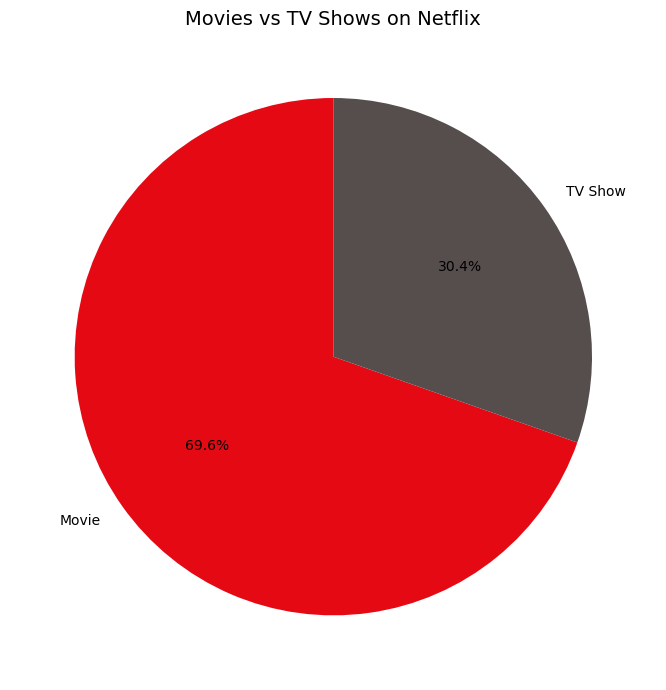

In [223]:
plt.figure(figsize=(7, 7))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914', '#564d4d'], startangle=90)
plt.title('Movies vs TV Shows on Netflix', fontsize=14)
plt.tight_layout()
plt.savefig('1_movies_vs_tvshows.png', dpi=150, bbox_inches='tight')
plt.show()

#### Movies make up nearly 70% of Netflix's catalog, showing the platform leans more toward films than series.

##### 2. How has the number of titles added to Netflix increased from year to year?

In [225]:
df_dated = net_df.dropna(subset=['date_added'])
growth = df_dated.groupby(df_dated['date_added'].dt.year)['show_id'].count()
growth

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: show_id, dtype: int64

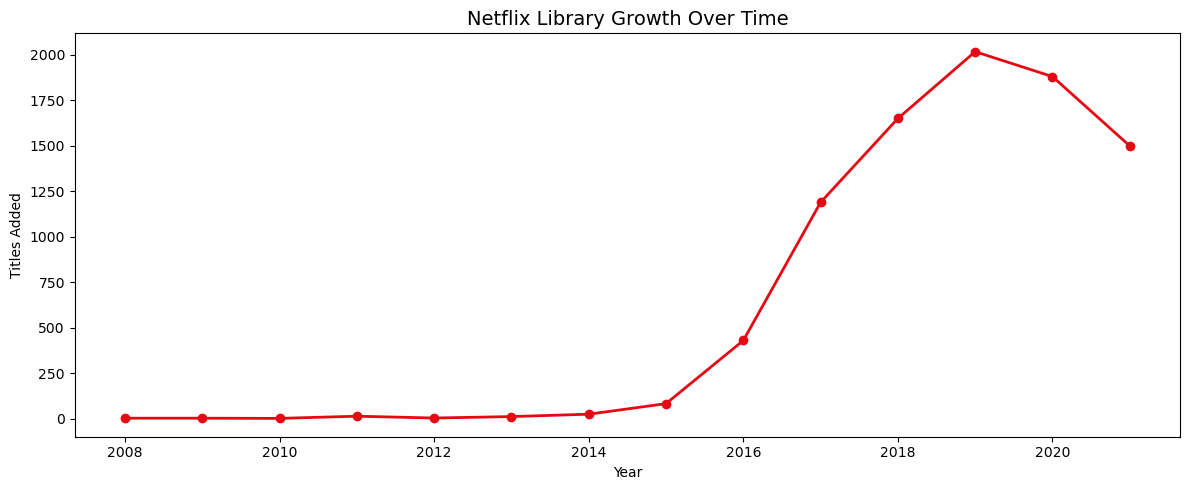

In [167]:
plt.figure(figsize=(12, 5))
plt.plot(growth.index, growth.values, color='#E50914', linewidth=2, marker='o')
plt.title('Netflix Library Growth Over Time', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.tight_layout()
plt.savefig('2_library_growth.png', dpi=150, bbox_inches='tight')
plt.show()

#### Netflix's library grew steadily from 2014, peaking around 2019-2020 before slowing down — likely reflecting a shift in strategy from quantity to quality.

##### 3. Which countries produce the most content available on Netflix?

In [226]:
top_countries = (net_df[net_df['country'] != 'Unknown']['country']
                 .str.split(', ').explode()
                 .value_counts().head(10))
top_countries

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

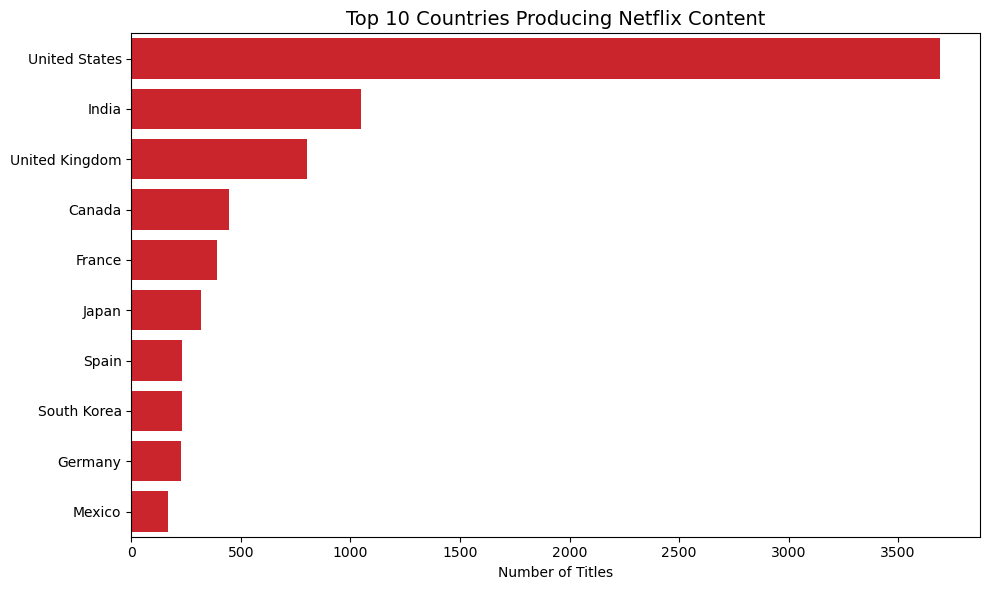

In [227]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, color='#E50914')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.savefig('3_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

#### The United States dominates Netflix's content supply by a wide margin, followed by India — highlighting the strong influence of Hollywood and Bollywood

##### 4. What are the most popular content genres on Netflix?

In [228]:
top_genres = (net_df['listed_in'].str.split(', ')
              .explode().value_counts().head(10))
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

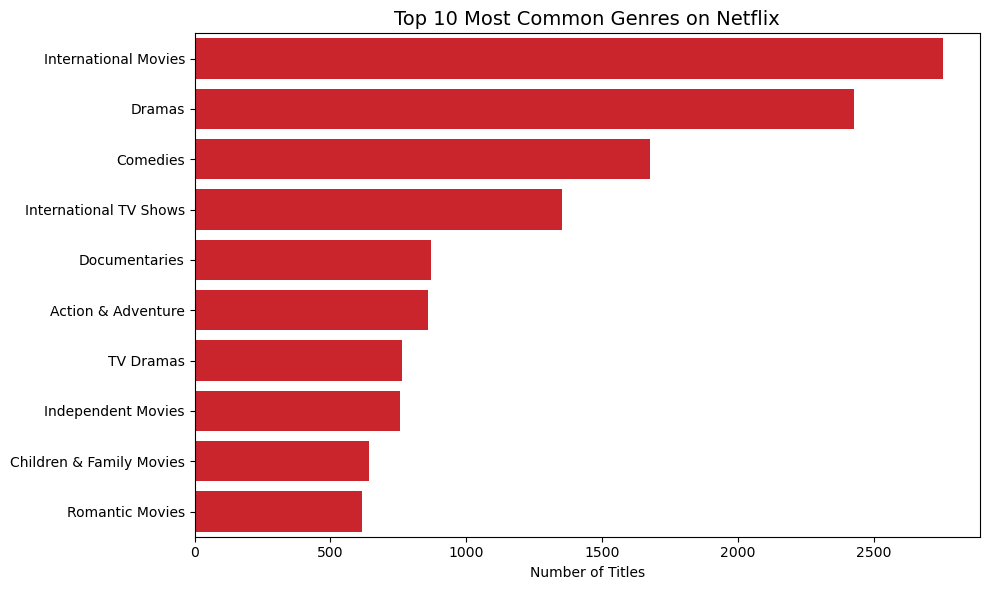

In [229]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, color='#E50914')
plt.title('Top 10 Most Common Genres on Netflix', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.savefig('4_top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

#### International Movies and Dramas are the most common genres, reflecting Netflix's heavy investment in global and emotionally driven content.

##### 5. What age ratings are most common across Netflix titles?

In [230]:
rating_counts = net_df[net_df['rating'] != 'Unknown']['rating'].value_counts()
rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

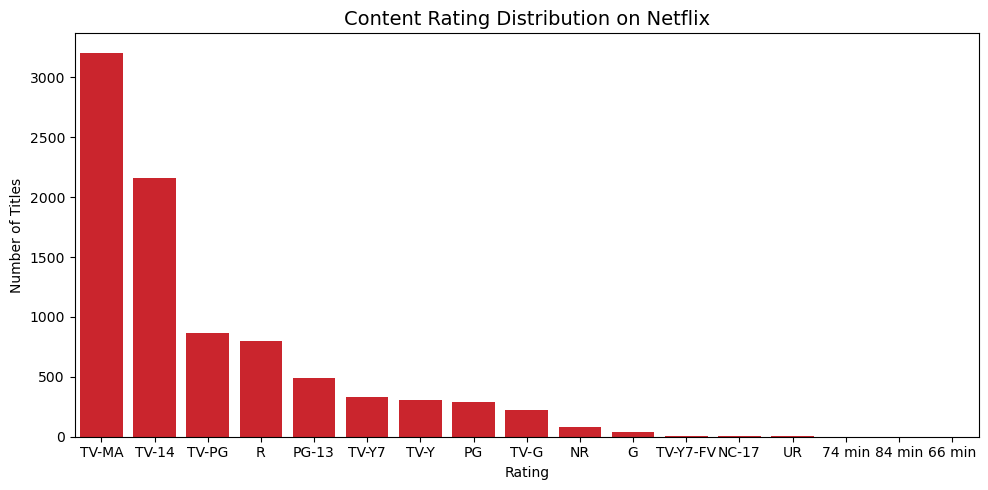

In [231]:
plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, color='#E50914')
plt.title('Content Rating Distribution on Netflix', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('5_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### TV-MA is the most common rating, meaning the majority of Netflix's catalog targets adult audiences rather than families or children.

##### 6. How long are most Netflix movies, and what is the typical runtime?

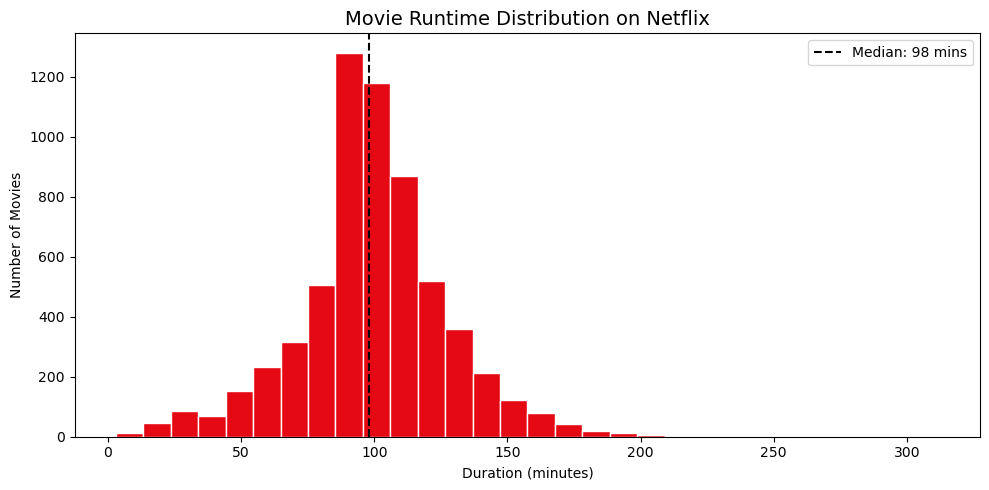

In [232]:
plt.figure(figsize=(10, 5))
plt.hist(movies['duration_mins'].dropna(), bins=30, color='#E50914', edgecolor='white')
plt.axvline(movies['duration_mins'].median(), color='black', linestyle='--',
            linewidth=1.5, label=f"Median: {movies['duration_mins'].median():.0f} mins")
plt.title('Movie Runtime Distribution on Netflix', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.legend()
plt.tight_layout()
plt.savefig('6_movie_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

#### Most Netflix movies fall between 80 and 120 minutes, which aligns with the standard runtime for feature films.

##### 7. How many seasons do most Netflix TV shows run for?

In [233]:
seasons_counts = tv['duration_seasons'].value_counts().sort_index().head(10)
seasons_counts

duration_seasons
1     1793
2      425
3      199
4       95
5       65
6       33
7       23
8       17
9        9
10       7
Name: count, dtype: Int64

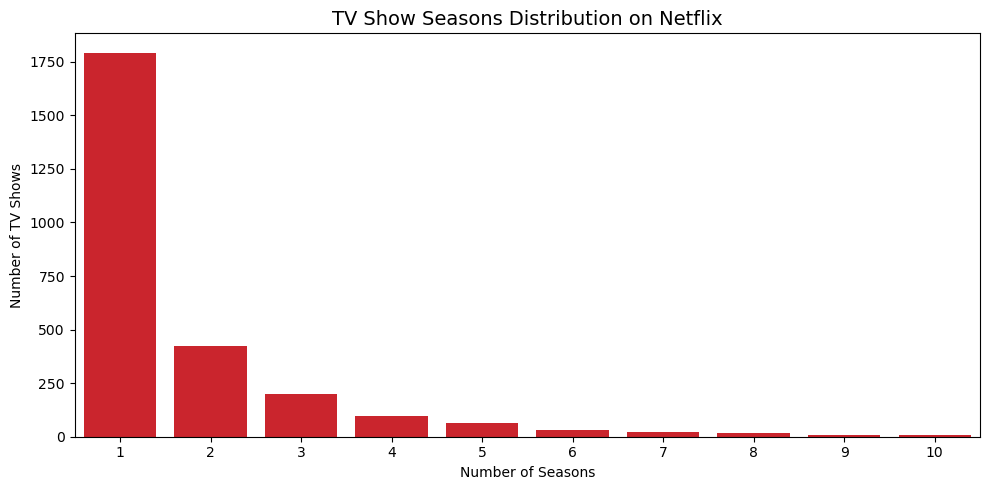

In [234]:
plt.figure(figsize=(10, 5))
sns.barplot(x=seasons_counts.index, y=seasons_counts.values, color='#E50914')
plt.title('TV Show Seasons Distribution on Netflix', fontsize=14)
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.tight_layout()
plt.savefig('7_tv_seasons.png', dpi=150, bbox_inches='tight')
plt.show()

#### The majority of Netflix TV shows run for just 1 season

##### 8. Which actors appear most frequently across Netflix titles?

In [235]:
top_cast = (df['cast'].str.split(', ').explode().value_counts().drop('Unknown').head(10))

print(top_cast)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


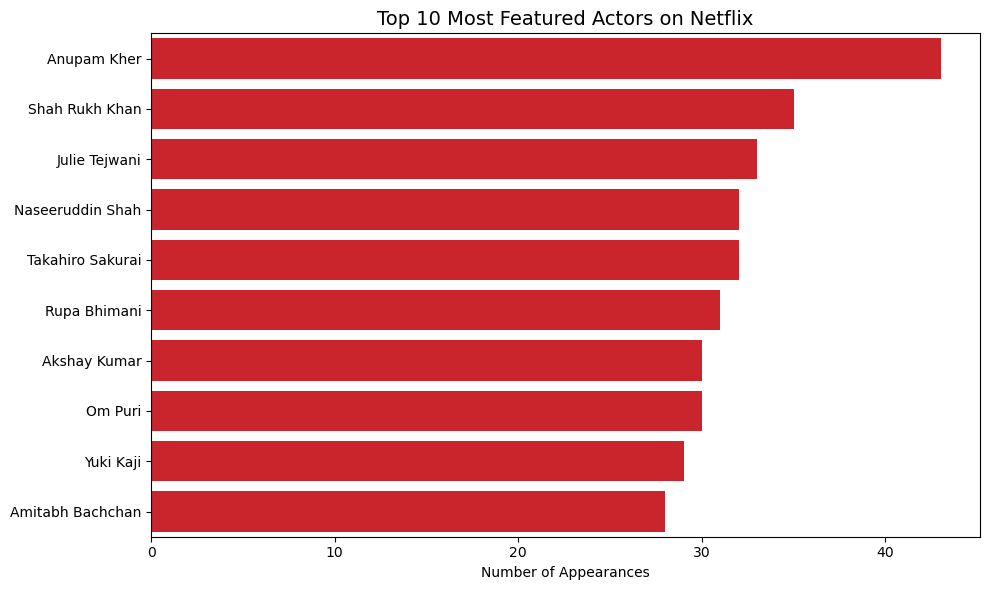

In [236]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_cast.values, y=top_cast.index, color='#E50914')
plt.title('Top 10 Most Featured Actors on Netflix', fontsize=14)
plt.xlabel('Number of Appearances')
plt.ylabel('')
plt.tight_layout()
plt.savefig('8_top_actors.png', dpi=150, bbox_inches='tight')
plt.show()

####  Bollywood actors dominate the most featured list, with Anupam Kher appearing in 43 titles across the platform

## Conclusion

From this analysis, a few clear patterns emerge about how Netflix builds its catalog:

- Netflix is primarily a movie platform, with films making up about 70% of all titles
- Content addition peaked around 2019–2020 and has since slowed down
- The United States and India are the largest content contributors
- Most content targets adult audiences, with TV-MA being the dominant rating
- Netflix favors short-run series, with most TV shows lasting only one season
- Bollywood and anime industries have a strong presence across the platform's catalog

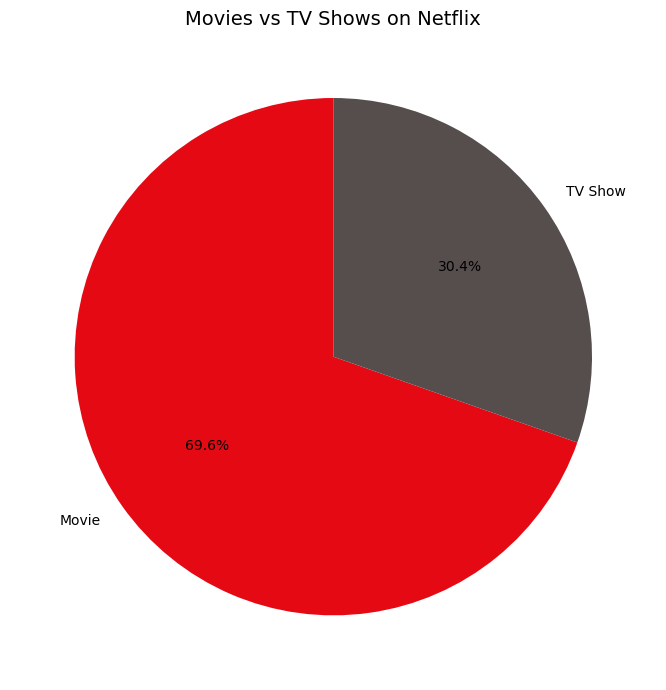

In [139]:
type_counts = net_df['type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914', '#564d4d'], startangle=90)
plt.title('Movies vs TV Shows on Netflix', fontsize=14)
plt.tight_layout()
plt.savefig('1_movies_vs_tvshows.png', dpi=150, bbox_inches='tight')
plt.show()